In [1]:
import matplotlib.pyplot as plt # type: ignore
import torch # type: ignore
from src.CasiaWebface import CasiaWebface # type: ignore
from src.Detector import Detector # type: ignore
from PIL import Image, ImageDraw # type: ignore

In [2]:
dataset = CasiaWebface(rec_path='./data/casia-webface/train.rec',
                       idx_path='./data/casia-webface/train.idx')
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)
detector = Detector(model_path='./models/yolov8n-face.pt')

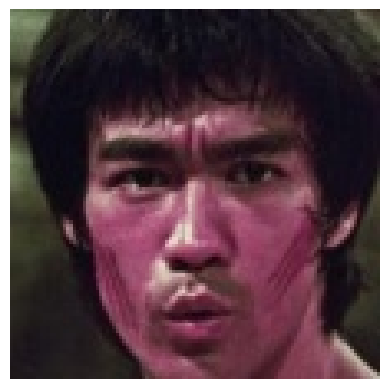

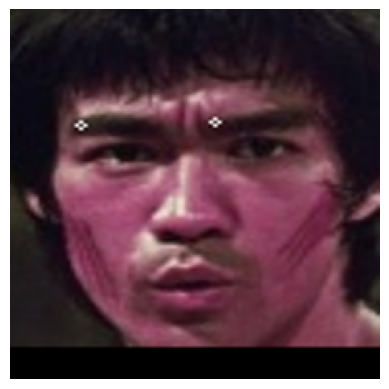

In [3]:
image, label = dataset[2]
plt.axis('off')
plt.imshow(image)
plt.show()
image, left_eye, right_eye = detector(image)
draw = ImageDraw.Draw(image)
if image is not None:
    draw.ellipse((left_eye[0] - 1, left_eye[1] - 1, left_eye[0] + 1, left_eye[1] + 1))
    draw.ellipse((right_eye[0] - 1, right_eye[1] - 1, right_eye[0] + 1, right_eye[1] + 1))
    plt.axis('off')
    image = image.resize((224, 224))
    plt.imshow(image)
    plt.show()
else:
    print('No faces detected')